In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.data_import import load_fashion_mnist
from src.model import EBM, EnergyHead, EBM_Old
from src.plot import visualize_heads, visualize_head_gradients, visualize_head_abs_gradients, show_grid, show_single_sample
from src.sampler import ReplaySampler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Data
TRAIN_CLASSES = [9]
BS = 32
IMG_SHAPE = (1, 28, 28)

# Model
N_HEADS = 3

# Sampler
BUFFER_SIZE = 8
NOISE_FRACTION = 0.05
NOISE_STD = 0.005

In [3]:
train_loader, test_loader  = load_fashion_mnist(batch_size=BS, class_subset=TRAIN_CLASSES)

In [4]:
model = EBM_Old(in_dim=28*28, mid_dim=150, n_heads=N_HEADS, batch_size=BS)
model.load_state_dict(torch.load("Models/FMNIST/ebm_boots_3heads_150mid_32bsz.pth", map_location=DEVICE, weights_only=False))

sampler = ReplaySampler(model=model, img_shape=IMG_SHAPE, buffer_size=BUFFER_SIZE, noise_fraction=NOISE_FRACTION, device=DEVICE)


In [ ]:
sample = sampler.sample(batch_size=BS, step_size=10.0, noise_std=NOISE_STD, steps=1)

visualize_head_gradients(model = model, x=sample, device=DEVICE)

for _ in range(10):
    for _ in range(20):
        sample = sampler.langevin_step(x=sample)
    visualize_head_gradients(model = model, x=sample, device=DEVICE)


In [13]:
from src.diagnostic import diagnose
diagnose(model=model)

TypeError: diagnose() missing 4 required positional arguments: 'sampler', 'img_shape', 'train_loader', and 'test_loader'

In [56]:
def corrupt_square(img, l, device=None):
    """
    Corrompe un quadrato l x l in posizione random con noise uniforme.
    img: tensor [C, H, W] o [1, C, H, W]
    Ritorna: (img_corrotta, mask) con mask=1 dove il pixel è CORROTTO (da ricostruire)
    """
    device = device or img.device
    if img.dim() == 3:
        img = img.unsqueeze(0)
    img = img.clone().to(device)

    _, C, H, W = img.shape
    assert l < H and l < W, "il quadrato deve essere più piccolo dell'immagine"

    top = torch.randint(0, H - l + 1, (1,)).item()
    left = torch.randint(0, W - l + 1, (1,)).item()

    mask = torch.zeros(1, 1, H, W, device=device)
    mask[:, :, top:top+l, left:left+l] = 1.0

    noise_patch = torch.rand(1, C, l, l, device=device) * 2 - 1  # noise in [-1, 1]
    img_corrupt = img.clone()
    img_corrupt[:, :, top:top+l, left:left+l] = noise_patch

    return img_corrupt, mask

def reconstruct_masked(model, img_corrupt, mask, steps=200, step_size=10.0,
                        noise_std=0.005, grad_clip=0.03, device=None):
    """
    Langevin sampling che aggiorna SOLO i pixel dove mask==1,
    lasciando il resto identico all'immagine corrotta in input.
    """
    device = device or next(model.parameters()).device
    was_training = model.training
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    x = img_corrupt.clone().to(device)
    original = img_corrupt.clone().to(device)  # parte non corrotta da preservare
    mask = mask.to(device)

    for _ in range(steps):
        x = x.detach()
        noise = torch.randn_like(x) * noise_std
        x = (x + noise * mask).clamp(-1.0, 1.0)  # noise solo dove serve

        with torch.enable_grad():
            x.requires_grad_(True)
            energy = model(x)[0].sum()
            grad = torch.autograd.grad(energy, x, only_inputs=True)[0]

        grad = grad.detach().clamp(-grad_clip, grad_clip)
        x = (x.detach() - step_size * grad * mask).clamp(-1.0, 1.0)  # update solo mascherato

        # forza i pixel non corrotti a restare esattamente uguali all'originale
        x = x * mask + original * (1 - mask)

    for p in model.parameters():
        p.requires_grad_(True)
    model.train(was_training)

    return x

def corrupt_salt_pepper(img, amount=0.1, device=None):
    """
    Aggiunge salt & pepper noise su tutta l'immagine.
    amount: frazione di pixel corrotti (es 0.1 = 10%)
    """
    device = device or img.device
    if img.dim() == 3:
        img = img.unsqueeze(0)
    img = img.clone().to(device)

    _, C, H, W = img.shape
    img_corrupt = img.clone()

    rand = torch.rand(1, 1, H, W, device=device)
    salt_mask = (rand < amount / 2)
    pepper_mask = (rand > 1 - amount / 2)

    img_corrupt[salt_mask.expand(-1, C, -1, -1)] = 1.0   # salt = bianco
    img_corrupt[pepper_mask.expand(-1, C, -1, -1)] = -1.0  # pepper = nero

    return img_corrupt

def denoise_langevin(model, img_corrupt, steps=200, step_size=10.0,
                      noise_std=0.005, grad_clip=0.03, device=None):
    """
    Langevin sampling classico partendo dall'immagine rumorosa
    invece che da puro noise. Nessuna maschera: tutta l'immagine è libera di evolvere.
    """
    device = device or next(model.parameters()).device
    was_training = model.training
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    x = img_corrupt.clone().to(device)

    for _ in range(steps):
        x = x.detach()
        noise = torch.randn_like(x) * noise_std
        x = (x + noise).clamp(-1.0, 1.0)

        with torch.enable_grad():
            x.requires_grad_(True)
            energy = model(x)[0].sum()
            grad = torch.autograd.grad(energy, x, only_inputs=True)[0]

        grad = grad.detach().clamp(-grad_clip, grad_clip)
        x = (x.detach() - step_size * grad).clamp(-1.0, 1.0)

    for p in model.parameters():
        p.requires_grad_(True)
    model.train(was_training)

    return x

def plot_reconstruction_demo(model, img, l=10, amount=0.15, steps=200,
                              step_size=10.0, noise_std=0.005, grad_clip=0.03,
                              device=None, cmap="gray"):
    """
    Mostra in un'unica figura:
    - immagine originale
    - inpainting: corrotta (quadrato) vs ricostruita
    - denoising: corrotta (salt&pepper) vs ricostruita
    Con l'energia E(x) del modello sotto ogni immagine.

    img: tensor [C, H, W] o [1, C, H, W]
    """
    device = device or next(model.parameters()).device
    if img.dim() == 3:
        img = img.unsqueeze(0)
    img = img.to(device)

    # --- Inpainting ---
    img_square, mask = corrupt_square(img, l=l, device=device)
    img_reconstructed = reconstruct_masked(
        model, img_square, mask, steps=steps, step_size=step_size,
        noise_std=noise_std, grad_clip=grad_clip, device=device
    )

    # --- Denoising ---
    img_sp = corrupt_salt_pepper(img, amount=amount, device=device)
    img_denoised = denoise_langevin(
        model, img_sp, steps=steps, step_size=step_size,
        noise_std=noise_std, grad_clip=grad_clip, device=device
    )

    # --- Calcolo energie ---
    def get_energy(x):
        model.eval()
        with torch.no_grad():
            e, _ = model(x)
        return e.sum().item()  # scalare, somma nel caso ci fossero più elementi/head

    imgs = [img, img_square, img_reconstructed, img_sp, img_denoised]
    titles = ["Original", "Corrupted", "Reconstructed\n(inpainting)",
              "Corrupted\n(salt & pepper noise)", "Reconstructed\n(denoising)"]
    energies = [get_energy(im) for im in imgs]

    # --- Plot ---
    fig, axes = plt.subplots(1, 5, figsize=(15, 3.6))

    for ax, im, title, e in zip(axes, imgs, titles, energies):
        im_np = im[0].detach().cpu().clamp(-1, 1)
        if im_np.shape[0] == 1:
            im_np = im_np.squeeze(0)
        else:
            im_np = im_np.permute(1, 2, 0)

        ax.imshow(im_np, cmap=cmap, vmin=-1, vmax=1)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
        ax.text(0.5, -0.08, f"E = {e:.4g}", transform=ax.transAxes,
                 ha="center", va="top", fontsize=10)

    plt.tight_layout()
    plt.show()

    return {
        "original": img,
        "corrupted_square": img_square,
        "reconstructed": img_reconstructed,
        "mask": mask,
        "corrupted_salt_pepper": img_sp,
        "denoised": img_denoised,
        "energies": dict(zip(titles, energies)),
    }

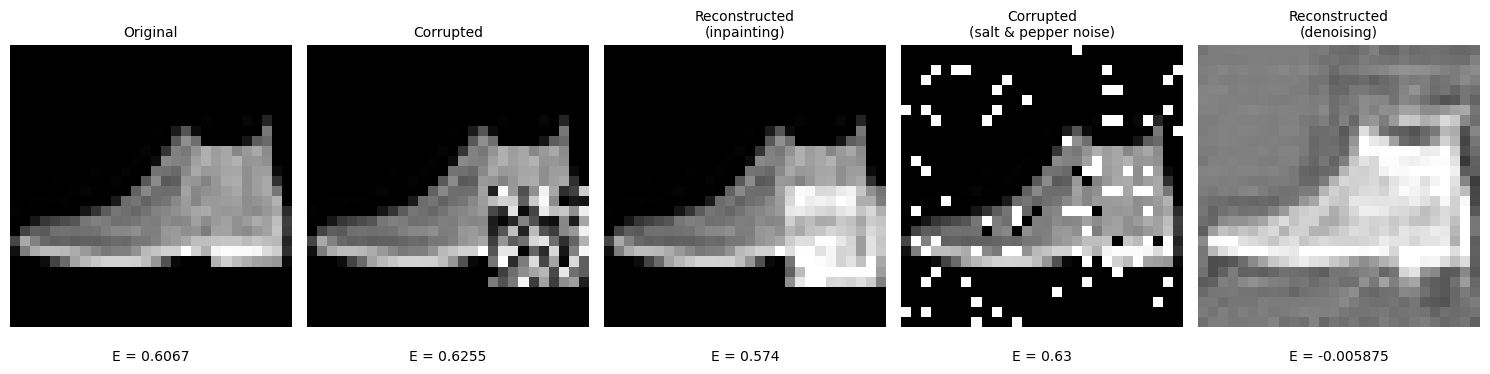

In [60]:
# Prendi un singolo batch dal loader
data_iter = iter(test_loader) 
batch, labels = next(data_iter)

img = batch[0:1].to(DEVICE)  # [1, C, H, W], stesso formato di prima

results = plot_reconstruction_demo(model, img, l=10, amount=0.15, steps=200, device=DEVICE)


In [61]:
from PIL import Image
import torchvision.transforms as T

def jpg_to_tensor(path, img_size=28, grayscale=True, normalize=True, device=None):
    """
    Carica un jpg e lo converte in tensor [1, C, H, W] pronto per il modello.

    img_size: resize a (img_size, img_size) — usa la stessa size del training
    grayscale: True se il modello lavora in scala di grigi (es. FashionMNIST)
    normalize: True per portare i valori in [-1, 1] (coerente col resto del pipeline)
    """
    device = device or "cpu"

    img = Image.open(path)
    if grayscale:
        img = img.convert("L")  # 1 canale
    else:
        img = img.convert("RGB")

    transform_list = [
        T.Resize((img_size, img_size)),
        T.ToTensor(),  # -> [C, H, W] in [0, 1]
    ]
    if normalize:
        mean = [0.5] * (1 if grayscale else 3)
        std = [0.5] * (1 if grayscale else 3)
        transform_list.append(T.Normalize(mean, std))  # -> [-1, 1]

    transform = T.Compose(transform_list)
    x = transform(img).unsqueeze(0)  # [1, C, H, W]

    return x.to(device)

def plot_two_images_with_energy(model, img1, img2, title1="Image 1", title2="Image 2",
                                 device=None, cmap="gray"):
    """
    Plotta due immagini una a fianco all'altra con titoli ed energia E(x) sotto ognuna.

    img1, img2: tensor [C, H, W] o [1, C, H, W]
    """
    device = device or next(model.parameters()).device

    def prep(im):
        if im.dim() == 3:
            im = im.unsqueeze(0)
        return im.to(device)

    def get_energy(x):
        model.eval()
        with torch.no_grad():
            e, _ = model(x)
        return e.sum().item()

    img1 = prep(img1)
    img2 = prep(img2)

    e1 = get_energy(img1)
    e2 = get_energy(img2)

    fig, axes = plt.subplots(1, 2, figsize=(6, 3.6))

    for ax, im, title, e in zip(axes, [img1, img2], [title1, title2], [e1, e2]):
        im_np = im[0].detach().cpu().clamp(-1, 1)
        if im_np.shape[0] == 1:
            im_np = im_np.squeeze(0)
        else:
            im_np = im_np.permute(1, 2, 0)

        ax.imshow(im_np, cmap=cmap, vmin=-1, vmax=1)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
        ax.text(0.5, -0.08, f"E = {e:.4g}", transform=ax.transAxes,
                 ha="center", va="top", fontsize=10)

    plt.tight_layout()
    plt.show()

    return {"energy_1": e1, "energy_2": e2}

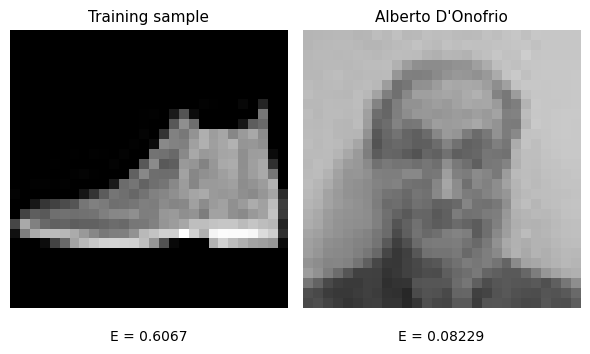

{'energy_1': 0.6066702604293823, 'energy_2': 0.08229416608810425}

In [65]:
img_custom = jpg_to_tensor("images/donofrio28.jpg", img_size=28, grayscale=True, device=DEVICE)
plot_two_images_with_energy(model, img, img_custom, title1="Training sample", title2="Alberto D'Onofrio")